# MNIST Test

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import sklearn
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from datetime import datetime

from src.data.datasets import sample_gaussian, plot_image
from src.models.models import (
    SimpleMLPVectorFieldND,
    TimeEmbeddingMLPVectorFieldND,
    MiniUNetVectorField,
)
from src.solver import integrate

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
NVIDIA GeForce RTX 5050 Laptop GPU


### Data Acquisition


In [3]:
# build dataloader
def get_mnist_dataloader(batch_size=128, data_dir="src/data"):
    """Download MNIST and return a configured DataLoader."""

    # Transform: Convert PIL Image to Tensor and normalize to [-1, 1]
    # Normalizing makes the flow matching process significantly more stable
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )

    # Download training dataset
    train_dataset = datasets.MNIST(
        root=data_dir, train=True, download=True, transform=transform
    )

    # Setup DataLoader
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, drop_last=True
    )

    return train_loader


def get_single_digit_mnist_dataloader(digit=8, batch_size=128, data_dir="src/data"):
    """Download MNIST and return a DataLoader filtering for a single digit."""

    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )

    # Load full dataset
    full_dataset = datasets.MNIST(
        root=data_dir, train=True, download=True, transform=transform
    )

    # Filter indices where target equals the specified digit
    indices = (full_dataset.targets == digit).nonzero(as_tuple=True)[0]

    # Create a subset with only that digit
    single_digit_subset = torch.utils.data.Subset(full_dataset, indices)

    # Setup DataLoader
    train_loader = torch.utils.data.DataLoader(
        single_digit_subset, batch_size=batch_size, shuffle=True, drop_last=True
    )

    return train_loader

In [4]:
dl_train = get_single_digit_mnist_dataloader(digit=8, batch_size=128)
dl_train_full = get_mnist_dataloader(batch_size=128)

torch.Size([128, 1, 28, 28])


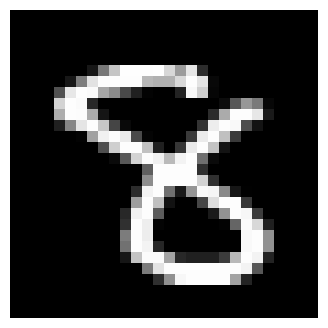

In [31]:
for batch in dl_train:
    images = batch[0]
    print(batch[0].shape)
    for i in images:
        plot_image(i)
        break
    break

torch.Size([1, 1, 28, 28])

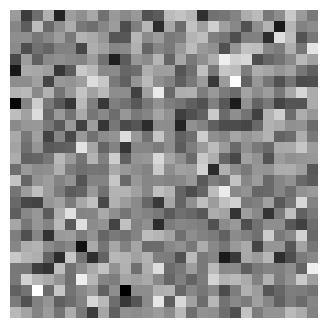

In [6]:
# testing the gaussian sampling in this high dimension

x0 = sample_gaussian(1, (1, 28, 28), "cpu")
plot_image(x0)
sample_gaussian(x0.shape[0], tuple(x0.shape[1:])).shape


## Training Procedure

In [32]:
def compute_conditional_flow(x1, device="cuda"):
    """Compute interpolations and targets using your custom sampler."""
    batch_size = x1.shape[0]

    # sampler for p0
    if len(x1.shape) == 4:
        # we expect shape (batch size, channel, height, width)
        x0 = sample_gaussian(batch_size, tuple(x1.shape[1:]), device=device)
    elif len(x1.shape) == 2:
        x0 = sample_gaussian(batch_size, dim=x1.shape[1], device=device)
    else:
        raise ValueError("Unknown shape for loss function.")

    # 2. Sample time steps t uniformly in [0, 1]
    t = torch.rand(batch_size, 1, device=device)

    # 3. Linear interpolation (path x_t)
    t_expanded = t.view(
        batch_size, *([1] * (len(x1.shape) - 1))
    )  # change shape / broadcasting
    xt = t_expanded * x1 + (1.0 - t_expanded) * x0

    # 4. Conditional vector field target (u_t)
    ut = x1 - x0

    return xt, t, ut


def cfm_loss(model, x1, device="cuda"):
    """Berechnet den mittleren quadratischen Fehler (MSE) zwischen vorhergesagtem

    und wahrem Vektorfeld.
    """
    xt, t, ut = compute_conditional_flow(x1, device)

    # the model tries to predict the vector field ut based on the position xt and time t
    vt = model(xt, t)

    # MSE Loss
    loss = torch.mean((vt - ut) ** 2)
    return loss


def train_step(model, optimizer, x1, loss_fn=cfm_loss, device="cuda"):
    """Performs a single training step: computes loss, backpropagates, and updates model parameters."""
    model.train()
    optimizer.zero_grad()
    loss = loss_fn(model, x1, device)
    loss.backward()
    optimizer.step()
    return loss.item()


def train_loop(
    model,
    optimizer,
    train_loader,
    n_epochs=1000,
    device="cuda",
    save_model=True,
    save_bestmodel=False,
    save_last_checkpoint=False,
    save_loss=True,
    plot_loss=True,
    folderpath="results",
):
    """Trains the model for a specified number of epochs."""
    loss_history = []
    for epoch in range(n_epochs):
        epoch_loss = 0
        n_batches = len(train_loader)
        for images, targets in train_loader:
            # only give the images, not the targets
            images = images.to(device)
            loss = train_step(model, optimizer, images, device=device)
            epoch_loss += loss.item() if hasattr(loss, "item") else loss
        # here simple avg-calculation since we drop the last, not-full batch
        epoch_avg_loss = epoch_loss / n_batches
        loss_history.append(epoch_avg_loss)

        if epoch == 0:
            print(f"Initial Loss: {loss:.4f}")
            min_loss = loss

        if loss < min_loss:
            min_loss = loss
            if save_bestmodel:
                store_model(model, folderpath=folderpath, filename="model_best")
        # elif (epoch + 1) % 100 == 0:
        #     print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss:.4f}")
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss:.4f}")

    if save_model:
        store_model(model, folderpath=folderpath, filename=None)
    if save_last_checkpoint:
        store_checkpoint(
            model,
            optimizer=optimizer,
            epoch=n_epochs,
            folderpath=folderpath,
            filename=None,
        )
    if save_loss:
        loss_path = os.path.join(folderpath, "loss_history")
        # save as pytorch file for later loading
        torch.save(loss_history, f"{loss_path}.pth")
        # csv with numpy
        loss_np = np.array(loss_history)
        np.savetxt(f"{loss_path}.csv", loss_np, fmt="%.6f")

        print(f"Loss history saved to {folderpath}")

    if plot_loss:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(loss_history)
        ax.set_title("Training Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        fig.savefig(
            os.path.join(folderpath, "loss_history.png"), dpi=300, bbox_inches="tight"
        )
        plt.close()
        os.startfile(os.path.join(folderpath, "loss_history.png"))

    return loss_history


def store_model(model, folderpath="results", filename=None):
    """Saves the model's state dictionary to a file."""

    daystamp = datetime.now().strftime("%m-%d-%y")

    if filename is None:
        filename = f"model_{daystamp}.pth"
    else:
        filename = f"{filename}_{daystamp}.pth"

    path = os.path.join(folderpath, filename)

    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def store_checkpoint(
    model, optimizer=None, epoch=None, folderpath="results", filename=None
):
    """Saves the model and optimizer state dictionaries to a file."""

    daystamp = datetime.now().strftime("%m-%d-%y")

    if filename is None:
        filename = f"model_{daystamp}.pth"
    else:
        filename = f"{filename}_{daystamp}.pth"

    path = os.path.join(folderpath, filename)

    checkpoint = {
        "model_state_dict": model.state_dict(),
    }
    if optimizer is not None:
        checkpoint["optimizer_state_dict"] = optimizer.state_dict()
    if epoch is not None:
        checkpoint["epoch"] = epoch

    torch.save(checkpoint, path)
    print(f"Model saved to {path}")

## Testing

In [33]:
def single_image_test(model, n_steps=10, h=1e-1, integrator="rk4"):
    x0 = sample_gaussian(1, (1, 28, 28), device="cuda")
    # plot_image(x0)
    x_final, trajectories = integrate(
        model, x0, n_steps=n_steps, h=h, integrator=integrator
    )
    plot_image(x_final.detach().cpu())

In [49]:
model = SimpleMLPVectorFieldND(28, 128).to("cuda")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_history = train_loop(
    model,
    optimizer,
    dl_train,
    10,
    device="cuda",
    save_model=False,
    save_loss=False,
    plot_loss=False,
)

Initial Loss: 1.2570
Epoch 1/10, Loss: 1.2570
Epoch 2/10, Loss: 1.2564
Epoch 3/10, Loss: 1.2234
Epoch 4/10, Loss: 1.2336
Epoch 5/10, Loss: 1.2278
Epoch 6/10, Loss: 1.2330
Epoch 7/10, Loss: 1.2334
Epoch 8/10, Loss: 1.2319
Epoch 9/10, Loss: 1.2478
Epoch 10/10, Loss: 1.2340


Integrating: 100%|██████████| 10/10 [00:00<00:00, 1051.78it/s]


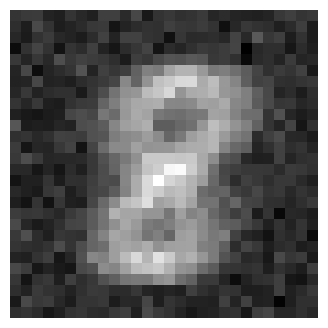

In [51]:
single_image_test(model, n_steps=10, h=1e-0, integrator="rk4")

## Time Embedding

In [9]:
model2 = TimeEmbeddingMLPVectorFieldND(28, 256, 64).to("cuda")
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
loss_history = train_loop(
    model2,
    optimizer2,
    dl_train_full,
    10,
    device="cuda",
    save_model=False,
    save_loss=False,
    plot_loss=False,
)

Initial Loss: 1.2644
Epoch 1/10, Loss: 1.2644
Epoch 2/10, Loss: 1.2707
Epoch 3/10, Loss: 1.2798
Epoch 4/10, Loss: 1.2550
Epoch 5/10, Loss: 1.2679
Epoch 6/10, Loss: 1.2558
Epoch 7/10, Loss: 1.2550
Epoch 8/10, Loss: 1.2745
Epoch 9/10, Loss: 1.2867
Epoch 10/10, Loss: 1.2618


Integrating: 100%|██████████| 10/10 [00:00<00:00, 402.39it/s]


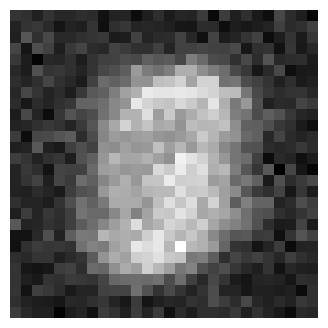

In [29]:
single_image_test(model2, n_steps=10, h=1e-0, integrator="rk4")

## UNet

In [61]:
model3 = MiniUNetVectorField().to("cuda")
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-3)
loss_history = train_loop(
    model3,
    optimizer3,
    dl_train,
    100,
    device="cuda",
    save_model=False,
    save_loss=False,
    plot_loss=False,
)

Initial Loss: 0.4535
Epoch 1/100, Loss: 0.4535
Epoch 2/100, Loss: 0.3500
Epoch 3/100, Loss: 0.2883
Epoch 4/100, Loss: 0.2916
Epoch 5/100, Loss: 0.2757
Epoch 6/100, Loss: 0.2591
Epoch 7/100, Loss: 0.2621
Epoch 8/100, Loss: 0.2434
Epoch 9/100, Loss: 0.2450
Epoch 10/100, Loss: 0.2324
Epoch 11/100, Loss: 0.2110
Epoch 12/100, Loss: 0.2260
Epoch 13/100, Loss: 0.2232
Epoch 14/100, Loss: 0.2305
Epoch 15/100, Loss: 0.2222
Epoch 16/100, Loss: 0.2101
Epoch 17/100, Loss: 0.1988
Epoch 18/100, Loss: 0.2314
Epoch 19/100, Loss: 0.2104
Epoch 20/100, Loss: 0.2182
Epoch 21/100, Loss: 0.2046
Epoch 22/100, Loss: 0.2182
Epoch 23/100, Loss: 0.2092
Epoch 24/100, Loss: 0.2134
Epoch 25/100, Loss: 0.1922
Epoch 26/100, Loss: 0.2057
Epoch 27/100, Loss: 0.2043
Epoch 28/100, Loss: 0.2047
Epoch 29/100, Loss: 0.2161
Epoch 30/100, Loss: 0.2075
Epoch 31/100, Loss: 0.1989
Epoch 32/100, Loss: 0.1904
Epoch 33/100, Loss: 0.2006
Epoch 34/100, Loss: 0.2050
Epoch 35/100, Loss: 0.1885
Epoch 36/100, Loss: 0.1996
Epoch 37/100, Lo

In [ ]:
model3 = MiniUNetVectorField().to("cuda")
model3

Integrating: 100%|██████████| 10/10 [00:00<00:00, 180.42it/s]


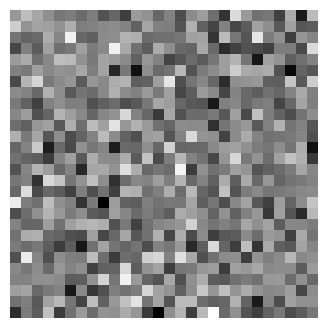

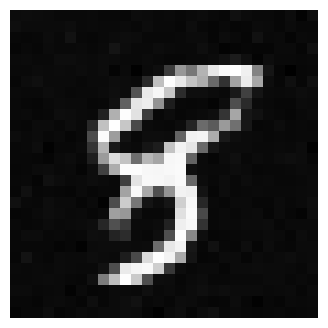

In [94]:
x0 = sample_gaussian(1, (1, 28, 28), device="cuda")
plot_image(x0)
x_final, trajectories = integrate(model3, x0, n_steps=10, h=1e-1, integrator="rk4")
plot_image(x_final.detach().cpu())

In [62]:
model4 = MiniUNetVectorField(fake=True).to("cuda")
optimizer4 = torch.optim.Adam(model4.parameters(), lr=1e-3)
loss_history = train_loop(
    model4,
    optimizer4,
    dl_train,
    100,
    device="cuda",
    save_model=False,
    save_loss=False,
    plot_loss=False,
)

Initial Loss: 0.4427
Epoch 1/100, Loss: 0.4427
Epoch 2/100, Loss: 0.3913
Epoch 3/100, Loss: 0.3179
Epoch 4/100, Loss: 0.3117
Epoch 5/100, Loss: 0.2718
Epoch 6/100, Loss: 0.2658
Epoch 7/100, Loss: 0.2564
Epoch 8/100, Loss: 0.2485
Epoch 9/100, Loss: 0.2417
Epoch 10/100, Loss: 0.2339
Epoch 11/100, Loss: 0.2419
Epoch 12/100, Loss: 0.2587
Epoch 13/100, Loss: 0.2392
Epoch 14/100, Loss: 0.2253
Epoch 15/100, Loss: 0.2344
Epoch 16/100, Loss: 0.1987
Epoch 17/100, Loss: 0.2372
Epoch 18/100, Loss: 0.2055
Epoch 19/100, Loss: 0.2225
Epoch 20/100, Loss: 0.2303
Epoch 21/100, Loss: 0.2075
Epoch 22/100, Loss: 0.2160
Epoch 23/100, Loss: 0.2205
Epoch 24/100, Loss: 0.2158
Epoch 25/100, Loss: 0.2266
Epoch 26/100, Loss: 0.2133
Epoch 27/100, Loss: 0.2126
Epoch 28/100, Loss: 0.2070
Epoch 29/100, Loss: 0.2087
Epoch 30/100, Loss: 0.2162
Epoch 31/100, Loss: 0.2149
Epoch 32/100, Loss: 0.2013
Epoch 33/100, Loss: 0.2032
Epoch 34/100, Loss: 0.2123
Epoch 35/100, Loss: 0.2269
Epoch 36/100, Loss: 0.2088
Epoch 37/100, Lo

Integrating: 100%|██████████| 10/10 [00:00<00:00, 128.86it/s]


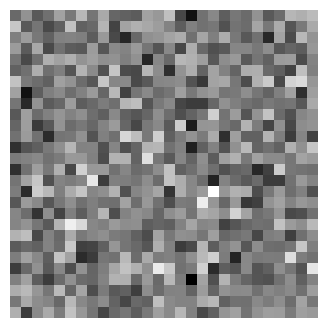

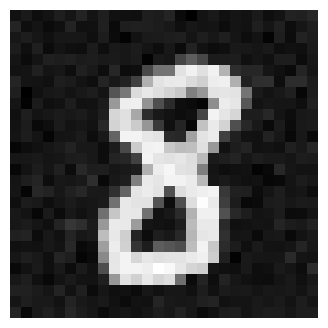

In [117]:
x0 = sample_gaussian(1, (1, 28, 28), device="cuda")
plot_image(x0)
x_final, trajectories = integrate(model4, x0, n_steps=10, h=1e-1, integrator="rk4")
plot_image(x_final.detach().cpu())

## FID-Score

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms
from tqdm import tqdm


def calculate_fid_for_flow_model(
    model, integrator, real_loader, num_samples=5000, batch_size=128, device="cuda"
):
    """
    Calculates the FID score comparing real MNIST images from real_loader
    with synthetic images generated by the flow matching model.

    Args:
        model: Your trained vector field network (e.g., MiniUNetVectorField)
        solver_fn: A function that takes (model, x0) and integrates from t=0 to t=1 using Euler/RK4
        real_loader: PyTorch DataLoader containing the real MNIST images
        num_samples: Total number of images to compare (5000 is a good trade-off)
        batch_size: Batch size for generation and feature extraction
        device: 'cuda' or 'cpu'
    """
    print("Initializing Inception-v3 for FID calculation...")
    # Initialize the torchmetrics FID object.
    # feature=2048 utilizes the final pooling layer of Inception-v3
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)

    # Transform to upscale 1x28x28 MNIST to 3x299x299 RGB expected by Inception
    preprocess = transforms.Compose(
        [
            transforms.Resize(
                (299, 299), interpolation=transforms.InterpolationMode.BILINEAR
            ),
            # If input is single channel, repeat it to 3 channels
            transforms.Lambda(lambda x: x.repeat(1, 3, 1, 1) if x.shape[1] == 1 else x),
            # Inception expects bytes [0, 255] for torchmetrics FID
            transforms.Lambda(
                lambda x: ((x + 1.0) * 127.5).clamp(0, 255).to(torch.uint8)
            ),
        ]
    )

    model.eval()
    samples_processed = 0

    print(f"Extracting features for {num_samples} real and generated images...")
    with torch.no_grad():
        for real_imgs, _ in tqdm(real_loader, desc="FID Loop"):
            if samples_processed >= num_samples:
                break

            current_batch_size = min(batch_size, num_samples - samples_processed)
            real_imgs = real_imgs[:current_batch_size].to(device)

            # 1. Generate synthetic samples via ODE integration
            # Start from pure Gaussian noise
            x0 = torch.randn(current_batch_size, 1, 28, 28, device=device)
            # Integrate using your solver (Euler or RK4) from t=0 to t=1
            gen_imgs = integrate(model, x0, n_steps=10, h=1e-1, integrator=integrator)[
                0
            ]

            # 2. Preprocess both domains for Inception-v3
            real_preprocessed = preprocess(real_imgs)
            gen_preprocessed = preprocess(gen_imgs)

            # 3. Update metric with real and fake batches
            fid_metric.update(real_preprocessed, real=True)
            fid_metric.update(gen_preprocessed, real=False)

            samples_processed += current_batch_size

    # Compute final Fréchet Distance
    final_fid = fid_metric.compute().item()
    print(f"\nFinal FID Score: {final_fid:.4f}")
    return final_fid


In [ ]:
fid = calculate_fid_for_flow_model(model3, "rk4", dl_train)

Initializing Inception-v3 for FID calculation...
Extracting features for 5000 real and generated images...


FID Loop:  89%|████████▉ | 40/45 [00:32<00:04,  1.23it/s]



Final FID Score: 40.7702


In [19]:
fid2 = calculate_fid_for_flow_model(model4, "rk4", dl_train)

Initializing Inception-v3 for FID calculation...
Extracting features for 5000 real and generated images...


FID Loop:  89%|████████▉ | 40/45 [00:31<00:03,  1.26it/s]



Final FID Score: 38.6814


In [124]:
from src.flow_engine import store_model

In [ ]:
store_model(model3, filename="Unet_w_time_emb")

Model saved to results\Unet_w_time_emb_06-08-26.pth


In [ ]:
store_model(model4, filename="Unet_wo_time_emb")

Model saved to results\Unet_wo_time_emb_06-08-26.pth


Integrating: 100%|██████████| 10/10 [00:00<00:00, 34.00it/s]


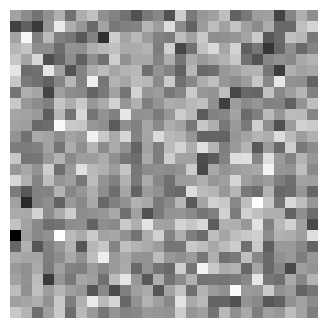

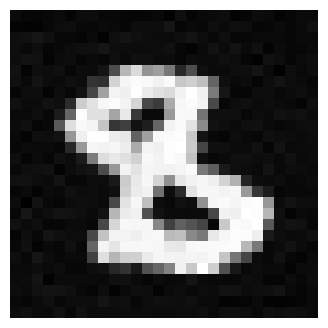

In [ ]:
model4 = MiniUNetVectorField().to("cuda")
model4.load_state_dict(
    torch.load("results/Unet_wo_time_emb_06-08-26.pth", weights_only=True)
)
x0 = sample_gaussian(1, (1, 28, 28), device="cuda")
plot_image(x0)
x_final, trajectories = integrate(model4, x0, n_steps=10, h=1e-1, integrator="rk4")
plot_image(x_final.detach().cpu())

Integrating: 100%|██████████| 10/10 [00:00<00:00, 112.84it/s]


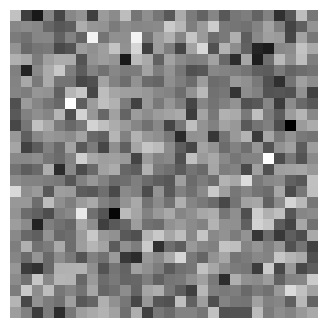

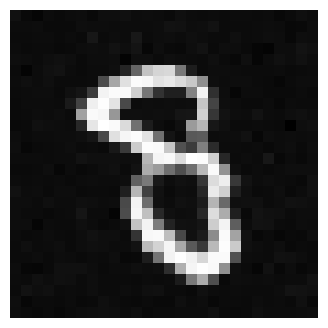

In [ ]:
model3 = MiniUNetVectorField().to("cuda")
model3.load_state_dict(
    torch.load("results/Unet_w_time_emb_06-08-26.pth", weights_only=True)
)
x0 = sample_gaussian(1, (1, 28, 28), device="cuda")
plot_image(x0)
x_final, trajectories = integrate(model3, x0, n_steps=10, h=1e-1, integrator="rk4")
plot_image(x_final.detach().cpu())

## Full Data Set

In [ ]:
model5 = MiniUNetVectorField().to("cuda")
optimizer5 = torch.optim.Adam(model5.parameters(), lr=1e-3)
loss_history = train_loop(
    model5,
    optimizer5,
    dl_train_full,
    10,
    device="cuda",
    save_model=False,
    save_loss=False,
    plot_loss=False,
)

Initial Loss: 0.2135
Epoch 1/10, Loss: 0.2135
Epoch 2/10, Loss: 0.2066
Epoch 3/10, Loss: 0.1958
Epoch 4/10, Loss: 0.1900
Epoch 5/10, Loss: 0.1924
Epoch 6/10, Loss: 0.1954
Epoch 7/10, Loss: 0.2043
Epoch 8/10, Loss: 0.1874
Epoch 9/10, Loss: 0.2061
Epoch 10/10, Loss: 0.1777


In [53]:
model5 = MiniUNetVectorField().to("cuda")
model5.load_state_dict(
    torch.load("results/UNet_full_MNIST_w_t_emb_06-08-26.pth", weights_only=True)
)

<All keys matched successfully>

Integrating: 100%|██████████| 10/10 [00:00<00:00, 146.97it/s]


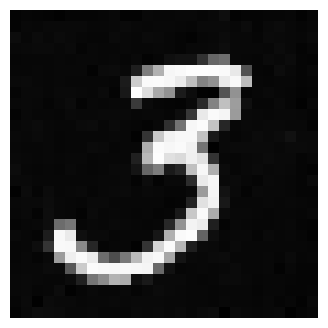

In [75]:
single_image_test(model5)

In [38]:
model6 = MiniUNetVectorField(fake=True).to("cuda")
optimizer6 = torch.optim.Adam(model6.parameters(), lr=1e-3)
loss_history = train_loop(
    model6,
    optimizer6,
    dl_train_full,
    10,
    device="cuda",
    save_model=False,
    save_loss=False,
    plot_loss=False,
)

Initial Loss: 0.2602
Epoch 1/10, Loss: 0.2602
Epoch 2/10, Loss: 0.2028
Epoch 3/10, Loss: 0.2099
Epoch 4/10, Loss: 0.2144
Epoch 5/10, Loss: 0.2029
Epoch 6/10, Loss: 0.1791
Epoch 7/10, Loss: 0.2160
Epoch 8/10, Loss: 0.2010
Epoch 9/10, Loss: 0.2096
Epoch 10/10, Loss: 0.2013


Integrating: 100%|██████████| 10/10 [00:00<00:00, 155.12it/s]


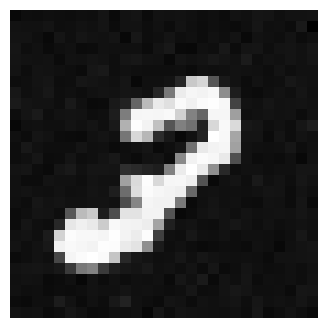

In [344]:
single_image_test(model6)

In [ ]:
store_model(model6, filename="UNet_full_MNIST_wo_t_emb")

Model saved to results\UNet_full_MNIST_wo_t_emb_06-08-26.pth


In [55]:
fid5 = calculate_fid_for_flow_model(model5, "rk4", dl_train_full)

Initializing Inception-v3 for FID calculation...
Extracting features for 5000 real and generated images...


FID Loop:   9%|▊         | 40/468 [00:32<05:49,  1.23it/s]



Final FID Score: 45.7194


In [56]:
fid6 = calculate_fid_for_flow_model(model6, "rk4", dl_train_full)

Initializing Inception-v3 for FID calculation...
Extracting features for 5000 real and generated images...


FID Loop:   9%|▊         | 40/468 [00:31<05:40,  1.26it/s]



Final FID Score: 57.5847


## Reloading Trained Models

In [ ]:
path = "results/26-06-10_0416_MNIST_ext_baseline/model_06-10-26.pth"

model = MiniUNetVectorField().to("cuda")
model.load_state_dict(torch.load(path, weights_only=True))

<All keys matched successfully>

Integrating: 100%|██████████| 10/10 [00:00<00:00, 157.16it/s]


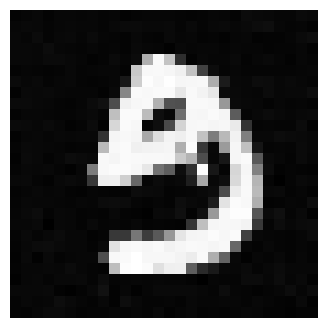

In [114]:
single_image_test(model)